<a href="https://colab.research.google.com/github/Rawan-fahad-eng/Color-Recognition-OpenCV/blob/main/Color_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
print("OpenCV version:", cv2.__version__)


OpenCV version: 4.13.0


الألوان المكتشفة: {'Red': 2, 'Red2': 1, 'Yellow': 3, 'Green': 1, 'Blue': 2, 'Orange': 1}


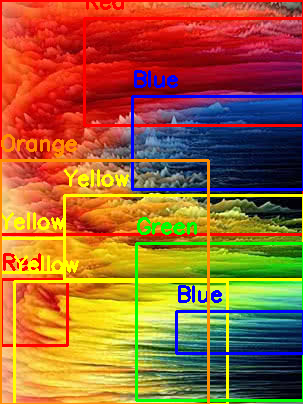

In [8]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# قراءة الصورة
image = cv2.imread('Appl.jpeg')
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# تحديد نطاقات الألوان المختلفة بصيغة HSV
colors = {
    "Red":    ([0, 120, 70], [10, 255, 255]),
    "Red2":   ([170, 120, 70], [180, 255, 255]),  # النطاق الثاني للأحمر
    "Yellow": ([20, 100, 100], [35, 255, 255]),
    "Green":  ([36, 60, 60], [85, 255, 255]),
    "Blue":   ([90, 60, 60], [130, 255, 255]),
    "Orange": ([10, 100, 100], [20, 255, 255]),
}

# ألوان الرسم لكل مربع (BGR)
draw_colors = {
    "Red": (0, 0, 255),
    "Red2": (0, 0, 255),
    "Yellow": (0, 255, 255),
    "Green": (0, 255, 0),
    "Blue": (255, 0, 0),
    "Orange": (0, 140, 255),
}

detected_count = {}

for color_name, (lower, upper) in colors.items():
    lower = np.array(lower)
    upper = np.array(upper)
    mask = cv2.inRange(hsv, lower, upper)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    count = 0
    for c in contours:
        if cv2.contourArea(c) > 500:
            x, y, w, h = cv2.boundingRect(c)
            label = "Red" if color_name == "Red2" else color_name
            cv2.rectangle(image, (x, y), (x + w, y + h), draw_colors[color_name], 2)
            cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, draw_colors[color_name], 2)
            count += 1
    if count > 0:
        detected_count[color_name] = count

print("الألوان المكتشفة:", detected_count)
cv2_imshow(image)
